# Annotation

This project explores a comprehensive hotel booking dataset containing reservations for both City Hotels and Resort Hotels. The primary objective is to perform data cleanup, visualize key booking trends, and statistically evaluate hypotheses regarding customer behavior. Key metrics analyzed include the length of stay, average daily rate (ADR), lead time, and the impact of special requests and family composition on booking outcomes.

# Getting project to work

In [23]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.cleaning import (
    load_raw_data,
    get_cleaning_summary,
    clean_data,
    save_clean_data,
    get_duplicate_count,
    get_total_missing_values
)

print("Imports work.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports work.


# Looking at the data

### Dataset description

This dataset contains hotel booking information for a City Hotel and a Resort Hotel.
Each row represents one hotel booking. The dataset includes information about
booking status, arrival date, length of stay, guests, room type, price, and
special requests.

### First look and import

In [24]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [25]:
df = load_raw_data()

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Checking the shape

In [26]:
df.shape

(119390, 32)

### Checking the columns

In [27]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

### Checking the df.info()

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Checking the df.describe()

In [29]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Checking the df.describe(include="object")

In [30]:
df.describe(include="object")

C:\Users\aleks\AppData\Local\Temp\ipykernel_13128\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


The raw dataset has `119390` rows and `32` columns. The columns include numerical
features such as `lead_time`, `adr`, `adults`, `children`, and categorical
features such as `hotel`, `meal`, `country`, and `customer_type`.

# Cleaning the data

In [31]:
get_cleaning_summary(df)

,dtype,missing_count,missing_percent,unique_values
company,float64,112593,94.306893,352
agent,float64,16340,13.686238,333
country,str,488,0.408744,177
children,float64,4,0.003350,5
arrival_date_month,str,0,0.000000,12
arrival_date_week_number,int64,0,0.000000,53
hotel,str,0,0.000000,2
is_canceled,int64,0,0.000000,2
stays_in_weekend_nights,int64,0,0.000000,17
arrival_date_day_of_month,int64,0,0.000000,31


In [32]:
df.duplicated().sum()

np.int64(31994)

In [33]:
df.isna().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

##### The `agent` and `company` columns are ID-like columns. Their numerical values are labels, not quantities, so mean/median/std would not be meaningful. Since they also contain many missing values and are not used in my hypotheses, I removed them.

##### Column "children" has only 4 missing values so it is better to treat these values as 0. Likely there were not any children.

##### Column "country" has decent amount of missing values so let just replace NaNs with "Unknown" as we don't know the country.

##### We can see that children are float64, it is better to make them as int.

##### Columns `is_canceled` and `is_repeated_guest` contain only 0 and 1. I keep them as integer binary columns because their mean can be interpreted as a rate.

##### Column "reservation_status_date" should be datetime for convinience.

### Understanding if there is any non-possible values

In [34]:
numeric_non_negative_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

for col in numeric_non_negative_cols:
    print(col, (df[col] < 0).sum())

lead_time 0
stays_in_weekend_nights 0
stays_in_week_nights 0
adults 0
children 0
babies 0
adr 1
required_car_parking_spaces 0
total_of_special_requests 0


##### There is a problem with one adr, we should investigate it

In [35]:
df[df["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


##### We should remove it 

### Understanding if there anywhere 0 guests

In [36]:
zero_guests = df[
    (df["adults"] == 0)
    & (df["children"] == 0)
    & (df["babies"] == 0)
]

zero_guests.shape

(180, 32)

##### There is such lines so we have to remove them.

### Getting clean DataFrame

In [37]:
clean_df = clean_data(df)

print("Before cleaning:", df.shape)
print("After cleaning:", clean_df.shape)

get_cleaning_summary(clean_df)

Before cleaning: (119390, 32)
After cleaning: (87203, 30)


,dtype,missing_count,missing_percent,unique_values
hotel,str,0,0.0,2
is_canceled,int64,0,0.0,2
lead_time,int64,0,0.0,479
arrival_date_year,int64,0,0.0,3
arrival_date_month,str,0,0.0,12
arrival_date_week_number,int64,0,0.0,53
arrival_date_day_of_month,int64,0,0.0,31
stays_in_weekend_nights,int64,0,0.0,17
stays_in_week_nights,int64,0,0.0,33
adults,int64,0,0.0,14


In [38]:
print(get_duplicate_count(clean_df))
print(get_total_missing_values(clean_df))

0
0


##### Now let's save the clean data

In [39]:
save_clean_data(clean_df)

In [40]:
check_df = pd.read_csv("../data/processed/hotel_bookings_clean.csv")

print(check_df.shape)
print(check_df.isna().sum().sum())
print(check_df.duplicated().sum())

(87203, 30)
0
0


### General Overview: Numerical Distributions
To understand the foundational shape of our data before comparing subsets, we visualize the basic distributions of four key numerical fields using Histograms, a Boxplot, and a Count (Bar) plot.

C:\Users\aleks\AppData\Local\Temp\ipykernel_13128\2461988887.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=clean_df['total_of_special_requests'], ax=axes[1,1], palette='Blues')


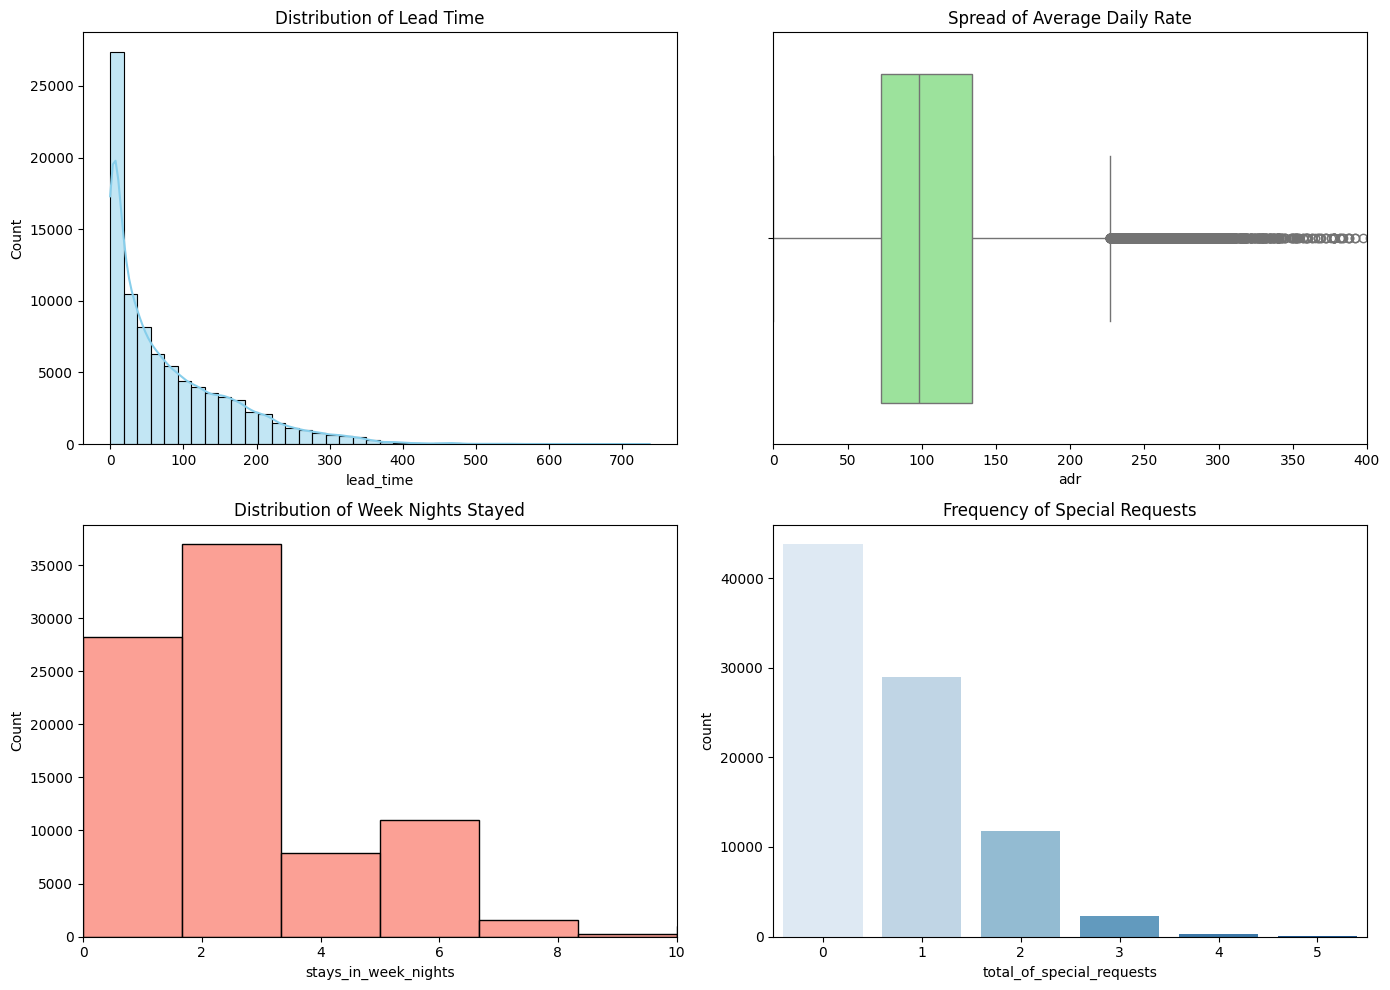

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram for Lead Time
sns.histplot(clean_df['lead_time'], bins=40, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribution of Lead Time')

# 2. Boxplot for ADR (Average Daily Rate)
sns.boxplot(x=clean_df['adr'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Spread of Average Daily Rate')
axes[0,1].set_xlim(0, 400) 

# 3. Histogram for Week Nights Stayed 
sns.histplot(clean_df['stays_in_week_nights'], bins=30, ax=axes[1,0], color='salmon')
axes[1,0].set_title('Distribution of Week Nights Stayed')
axes[1,0].set_xlim(0, 10)

# 4. Bar Plot for Special Requests 
sns.countplot(x=clean_df['total_of_special_requests'], ax=axes[1,1], palette='Blues')
axes[1,1].set_title('Frequency of Special Requests')

plt.tight_layout()
plt.show()

# Analysis of the data

In [42]:
clean_df = pd.read_csv("../data/processed/hotel_bookings_clean.csv")

In [43]:
clean_df['total_nights'] = clean_df['stays_in_weekend_nights'] + clean_df['stays_in_week_nights']
clean_df['has_children'] = (clean_df['children'] > 0) | (clean_df['babies'] > 0)
clean_df['has_special_requests'] = clean_df['total_of_special_requests'] > 0

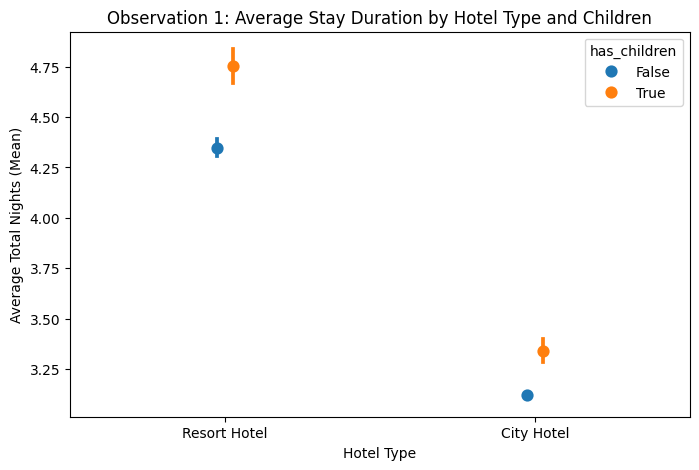

In [44]:
plt.figure(figsize=(8, 5))
sns.pointplot(data=clean_df, x='hotel', y='total_nights', hue='has_children', dodge=True, linestyles="")
plt.title("Observation 1: Average Stay Duration by Hotel Type and Children")
plt.xlabel("Hotel Type")
plt.ylabel("Average Total Nights (Mean)")
plt.show()

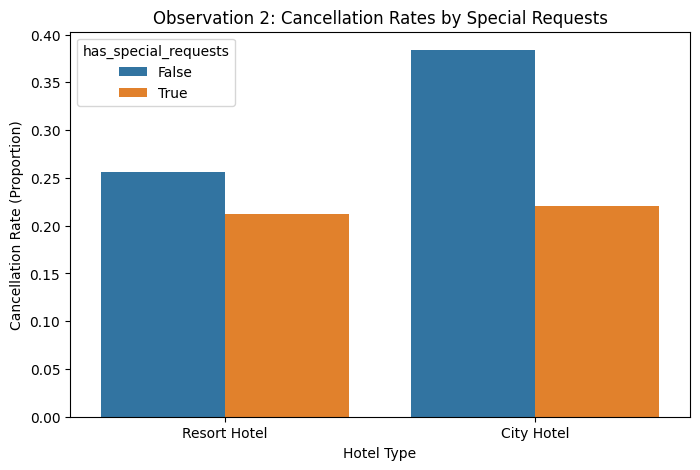

In [45]:
plt.figure(figsize=(8, 5))
sns.barplot(data=clean_df, x='hotel', y='is_canceled', hue='has_special_requests', errorbar=None)
plt.title("Observation 2: Cancellation Rates by Special Requests")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (Proportion)")
plt.show()

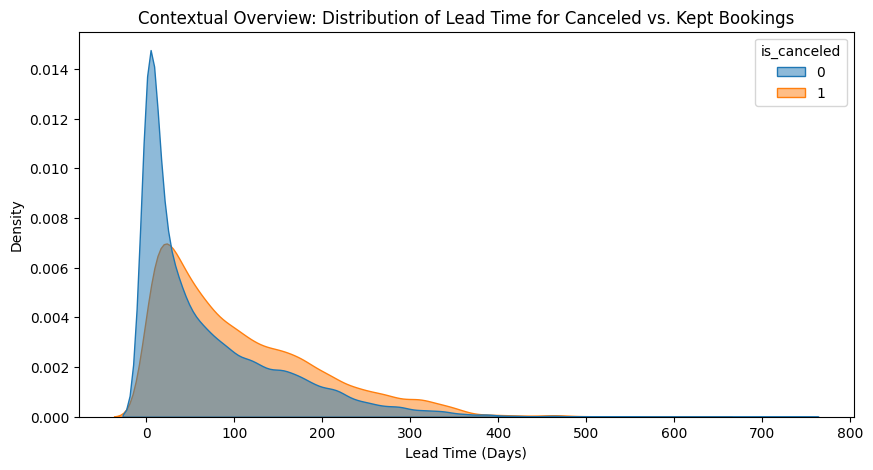

In [46]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=clean_df, x='lead_time', hue='is_canceled', common_norm=False, fill=True, alpha=0.5)
plt.title("Contextual Overview: Distribution of Lead Time for Canceled vs. Kept Bookings")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Density")
plt.show()

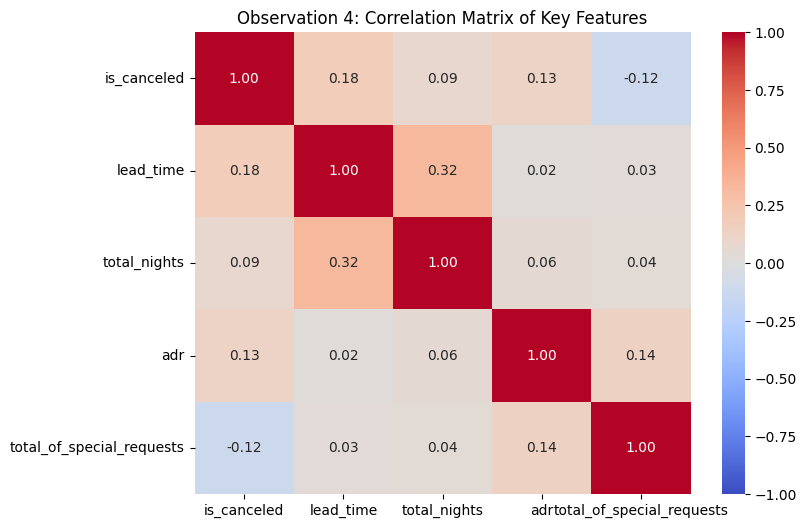

In [ ]:
plt.figure(figsize=(8, 6))
num_cols = ['is_canceled', 'lead_time', 'total_nights', 'adr', 'total_of_special_requests']
corr_matrix = clean_df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Observation 4: Correlation Matrix of Key Features")
plt.show()

### Hypothesis Formulation & Testing
**Discussion:** Visualizations can imply trends, but statistical rigor is required to confirm them. We will use the `scipy.stats` library to test our two primary observations.

**Hypothesis 1: Impact of Children on Stay Duration**
* **Observation:** Visual 1 implies families stay longer.
* **Null Hypothesis (H0):** There is no difference in the mean total nights stayed between guests with children and guests without.
* **Test Chosen:** Independent two-sample T-test (Welch's), as we are comparing the means of two continuous numerical distributions with potentially unequal variances.

**Hypothesis 2: Special Requests and Cancellations**
* **Observation:** Visual 2 shows a massive drop in cancellations when requests are made.
* **Null Hypothesis (H0):** Booking cancellation is completely independent of whether a guest makes special requests.
* **Test Chosen:** Chi-Square Test of Independence, because we are evaluating the relationship between two categorical/boolean variables.

In [ ]:
print("="*50)
print("TESTING HYPOTHESIS 1: Children vs. Stay Duration")
print("="*50)

with_children = clean_df[clean_df['has_children']]['total_nights']
without_children = clean_df[~clean_df['has_children']]['total_nights']

t_stat, p_val_1 = stats.ttest_ind(with_children, without_children, equal_var=False)

print(f"Mean nights (with children): {with_children.mean():.2f}")
print(f"Mean nights (no children): {without_children.mean():.2f}")
print(f"P-value: {p_val_1:.4e}")

if p_val_1 < 0.05:
    print("Conclusion: Reject the null hypothesis. The visual trend is confirmed statistically: guests with children stay significantly longer.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")
print("\n")

print("="*50)
print("TESTING HYPOTHESIS 2: Special Requests vs. Cancellations")
print("="*50)

contingency_table = pd.crosstab(clean_df['has_special_requests'], clean_df['is_canceled'])
print("Contingency Table (Columns: is_canceled 0/1):")
display(contingency_table)

chi2, p_val_2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"P-value: {p_val_2:.4e}")

if p_val_2 < 0.05:
    print("Conclusion: Reject the null hypothesis. The visual trend is confirmed statistically: there is a strong dependence between making special requests and not canceling.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

TESTING HYPOTHESIS 1: Children vs. Stay Duration
Mean nights (with children): 3.94
Mean nights (no children): 3.59
P-value: 8.4438e-34
Conclusion: Reject the null hypothesis. The visual trend is confirmed statistically: guests with children stay significantly longer.


TESTING HYPOTHESIS 2: Special Requests vs. Cancellations
Contingency Table (Columns: is_canceled 0/1):


is_canceled,0,1
has_special_requests,,
False,29213,14558
True,33985,9447


P-value: 0.0000e+00
Conclusion: Reject the null hypothesis. The visual trend is confirmed statistically: there is a strong dependence between making special requests and not canceling.


: 